# Arbitrary Two-Qubit Entangled State Using RY and CNOT

## 1. Objective
The objective of this experiment is to construct an arbitrary, parameterized two-qubit entangled quantum state using a tunable Pauli-Y rotation ($R_Y$) gate and a Controlled-NOT (CNOT) gate, and to verify its computational-basis state probabilities and normalization using exact statevector analysis.

---

## 2. Theory

### Initial State
The two-qubit quantum register begins in the standard ground state:

$$|\psi_0\rangle = |00\rangle = |0\rangle \otimes |0\rangle$$

### Parameterized Single-Qubit Rotation ($R_Y$)
The single-qubit $R_Y(\theta)$ gate performs a rotation of the state vector by an angle $\theta$ around the Y-axis of the Bloch sphere:

$$R_Y(\theta) = \exp\left(-i\frac{\theta}{2} Y\right) = \begin{pmatrix} \cos\left(\frac{\theta}{2}\right) & -\sin\left(\frac{\theta}{2}\right) \\ \sin\left(\frac{\theta}{2}\right) & \cos\left(\frac{\theta}{2}\right) \end{pmatrix}$$

Applying $R_Y(\theta)$ to the initial ground state of qubit 0 prepares a superposition with real-valued amplitudes:

$$R_Y(\theta)|0\rangle = \cos\left(\frac{\theta}{2}\right)|0\rangle + \sin\left(\frac{\theta}{2}\right)|1\rangle$$

The composite two-qubit separable state becomes:

$$|\psi_1\rangle = (R_Y(\theta) \otimes I)|00\rangle = \cos\left(\frac{\theta}{2}\right)|00\rangle + \sin\left(\frac{\theta}{2}\right)|10\rangle$$

### Creating Entanglement via CNOT
A CNOT gate is applied with qubit 0 as the control and qubit 1 as the target:
- When the control qubit is $|0\rangle$, the target remains $|0\rangle$: $|00\rangle \to |00\rangle$.
- When the control qubit is $|1\rangle$, the target is flipped from $|0\rangle$ to $|1\rangle$: $|10\rangle \to |11\rangle$.

This produces an arbitrary entangled two-qubit state of the form:

$$|\psi_2\rangle = \cos\left(\frac{\theta}{2}\right)|00\rangle + \sin\left(\frac{\theta}{2}\right)|11\rangle$$

### Probability Relationship with $\theta$
The measurement probabilities for the computational basis states are given by Born's rule:
$$P(|00\rangle) = \left|\cos\left(\frac{\theta}{2}\right)\right|^2 = \cos^2\left(\frac{\theta}{2}\right)$$
$$P(|11\rangle) = \left|\sin\left(\frac{\theta}{2}\right)\right|^2 = \sin^2\left(\frac{\theta}{2}\right)$$
$$P(|01\rangle) = P(|10\rangle) = 0$$

By tuning the angle $\theta$, the distribution of probability between $|00\rangle$ and $|11\rangle$ can be continuously adjusted while maintaining maximal correlation. When $\theta = \pi/2$, the state reduces to the canonical maximally entangled Bell state $|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}$.

## 3. Circuit Explanation
The circuit operates on 2 qubits:

1. **Parameter Definition**:
   - `theta = np.pi / 2.8`: Sets the rotation angle $\theta = \frac{5\pi}{14} \approx 1.1220$ radians ($64.29^\circ$), with half-angle $\frac{\theta}{2} = \frac{5\pi}{28} \approx 0.5610$ radians ($32.14^\circ$).
2. **$R_Y$ Rotation (`qc.ry(theta, 0)`)**:
   - Applied to the first qubit (`q_0`) to set the probability amplitude ratio $\cos(\theta/2) : \sin(\theta/2)$.
3. **CNOT Entangling Gate (`qc.cx(0, 1)`)**:
   - Uses the rotated first qubit (`q_0`) as control and the second qubit (`q_1`) as target.
   - Entangles $q_1$ with $q_0$ by mapping the $|10\rangle$ branch to $|11\rangle$.

---

## 4. Statevector Analysis
- **Exact Evaluation**: The circuit is analyzed using Qiskit's `Statevector.from_instruction(qc)`, computing the exact analytical state vector without stochastic shot noise or measurement collapse.
- **Probability Extraction**: Probabilities are computed directly from the amplitudes using `state.probabilities_dict()`, allowing precise evaluation of basis-state weights.


ARBITRARY ENTANGLED STATE CIRCUIT
     ┌───────────┐     
q_0: ┤ Ry(5π/14) ├──■──
     └───────────┘┌─┴─┐
q_1: ─────────────┤ X ├
                  └───┘

STATEVECTOR
Statevector([0.8467242 +0.j, 0.        +0.j, 0.        +0.j,
             0.53203208+0.j],
            dims=(2, 2))

BASIS STATE PROBABILITIES
|00> : 0.716942
|11> : 0.283058

NORMALIZATION CHECK
Total probability = 1.000000

THEORETICAL VALUES
P(00) = 0.716942
P(11) = 0.283058


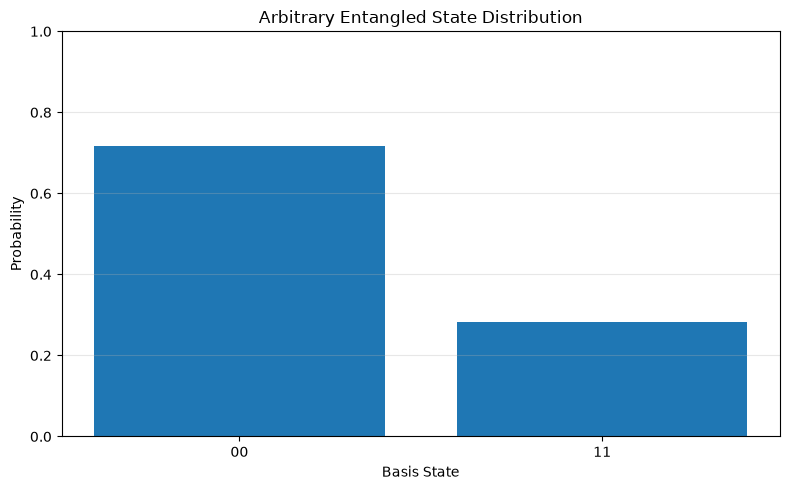

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

theta = np.pi / 2.8

qc = QuantumCircuit(2)

qc.ry(theta, 0)
qc.cx(0, 1)

print("\nARBITRARY ENTANGLED STATE CIRCUIT")
print("=" * 65)
print(qc.draw())

state = Statevector.from_instruction(qc)

print("\nSTATEVECTOR")
print("=" * 65)
print(state)

probabilities = state.probabilities_dict()

print("\nBASIS STATE PROBABILITIES")
print("=" * 65)

states = []
values = []

for basis_state, probability in probabilities.items():

    if probability > 1e-10:
        states.append(basis_state)
        values.append(probability)
        print(f"|{basis_state}> : {probability:.6f}")

print("\nNORMALIZATION CHECK")
print("=" * 65)

print(f"Total probability = {sum(values):.6f}")

theoretical_00 = np.cos(theta / 2) ** 2
theoretical_11 = np.sin(theta / 2) ** 2

print("\nTHEORETICAL VALUES")
print("=" * 65)
print(f"P(00) = {theoretical_00:.6f}")
print(f"P(11) = {theoretical_11:.6f}")

plt.figure(figsize=(8, 5))

plt.bar(states, values)

plt.xlabel("Basis State")
plt.ylabel("Probability")
plt.title("Arbitrary Entangled State Distribution")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Results and Observation

### Recorded Circuit and Statevector Outputs
Execution of the notebook generates the following output:

```
ARBITRARY ENTANGLED STATE CIRCUIT
=================================================================
     ┌───────────┐     
q_0: ┤ Ry(5π/14) ├──■──
     └───────────┘┌─┴─┐
q_1: ─────────────┤ X ├
                  └───┘

STATEVECTOR
=================================================================
Statevector([0.8467242 +0.j, 0.        +0.j, 0.        +0.j,
             0.53203208+0.j],
            dims=(2, 2))

BASIS STATE PROBABILITIES
=================================================================
|00> : 0.716942
|11> : 0.283058

NORMALIZATION CHECK
=================================================================
Total probability = 1.000000

THEORETICAL VALUES
=================================================================
P(00) = 0.716942
P(11) = 0.283058
```

### Amplitudes and Basis-State Probabilities
The statevector amplitudes and computed probabilities for all four computational-basis states are:

| Basis State | Amplitude | Measured Probability | Theoretical Formula | Theoretical Value |
|:-----------:|:---------:|:--------------------:|:-------------------:|:-----------------:|
| $|00\rangle$ | $0.8467242 + 0j$ | **0.716942** | $\cos^2(5\pi/28)$ | **0.716942** |
| $|01\rangle$ | $0.0000000 + 0j$ | **0.000000** | $0$ | **0.000000** |
| $|10\rangle$ | $0.0000000 + 0j$ | **0.000000** | $0$ | **0.000000** |
| $|11\rangle$ | $0.5320321 + 0j$ | **0.283058** | $\sin^2(5\pi/28)$ | **0.283058** |

### Key Observations
1. **Tunable Probabilities**: The state produces $P(|00\rangle) \approx 71.69\%$ and $P(|11\rangle) \approx 28.31\%$, matching theoretical expectations to six decimal places.
2. **Strict Correlation**: The anti-correlated states $|01\rangle$ and $|10\rangle$ have zero probability, proving that the two qubits remain strictly correlated despite having unequal amplitude weights.

## 6. Normalization Check
The sum of probabilities across all non-zero basis states evaluates to:
$$\sum_{x} P(x) = P(|00\rangle) + P(|11\rangle) = 0.716942 + 0.283058 = 1.000000$$

This verifies that the statevector is properly normalized ($\langle \psi | \psi \rangle = 1$), adhering strictly to the laws of quantum mechanics.

---

## 7. Visualization
The generated Matplotlib bar chart displays the probability distribution for the non-zero computational basis states:
- **$|00\rangle$ Bar**: Height of $0.716942$ ($71.69\%$).
- **$|11\rangle$ Bar**: Height of $0.283058$ ($28.31\%$).
- The plot visually illustrates the asymmetric, tunable weighting of the entangled state.

## 8. Conclusion
This experiment demonstrates how a parameterized single-qubit rotation ($R_Y$) combined with an entangling CNOT gate synthesizes a tunable two-qubit entangled state:

$$|\psi\rangle = \cos\left(\frac{\theta}{2}\right)|00\rangle + \sin\left(\frac{\theta}{2}\right)|11\rangle$$

Key takeaways:
1. **Continuous Tunability**: Parameter $\theta = \pi/2.8$ continuously controls the amplitude distribution between $|00\rangle$ and $|11\rangle$.
2. **Entangled Correlation**: The CNOT gate establishes complete two-qubit correlation, ensuring zero probability for anti-correlated states $|01\rangle$ and $|10\rangle$.
3. **Exact Analytical Validation**: Statevector analysis provides exact probability values and confirms state normalization ($\sum P_i = 1$) without statistical sampling error.